<a href="https://colab.research.google.com/github/shubham-maral/Facial-Emotion-Recognition-App/blob/main/final_facial_emotion_recognition_cnn_model_c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GitHub Link: https://github.com/shubham-maral/Facial-Emotion-Recognition-App

Introduction¶

The goal of this project is to develop a deep learning model that can accurately classify facial expressions into one of seven categories: Angry, Disgust, Fear, Happy, Sad, Surprise, and Neutral. We will use convolutional neural networks (CNNs) to train our model, as they have been shown to be effective in image classification tasks. Our approach involves training a CNN model from scratch.

Data¶

The FER-2013 dataset consists of 48x48 pixel grayscale images of faces that have been automatically registered to be centred and occupy a similar amount of space in each image. The dataset contains 24,400 images, with 22,968 examples in the training set and 1,432 examples in the public test set.

Preprocessing¶

In this section, we will be using both data generators and data augmentation to train a deep learning model for human emotion detection using the FER-2013 dataset. Due to the size and complexity of the dataset, it would be impractical to load all of the images into memory at once. Therefore, we will be using data generators to generate batches of images on-the-fly during training, which will allow us to efficiently train our model on the entire dataset.

In addition, we will be applying various data augmentation techniques to the training images, such as rotation, shifting, and flipping. This will help to increase the size and diversity of our training set, which can improve the performance of our deep learning model. By introducing variability into the training process, data augmentation can also help to prevent overfitting, which occurs when the model becomes too closely tailored to the training set and performs poorly on new, unseen data.

## **Installing Required Libraries**

In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

import keras
print("Keras version:", keras.__version__)

TensorFlow version: 2.20.0
Keras version: 3.13.2


In [3]:
# !pip install tensorflow==2.15.0 keras==2.15.0

In [4]:
tf.__version__

'2.20.0'

In [5]:
keras.__version__

'3.13.2'

In [6]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras.preprocessing import image
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten,Dense,Dropout,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from tensorflow.keras.applications import VGG16, InceptionResNetV2
from keras import regularizers
from tensorflow.keras.optimizers import Adam,RMSprop,SGD,Adamax

In [7]:
import tensorflow as tf
print("GPUs Available:", tf.config.list_physical_devices('GPU'))
print("TensorFlow version:", tf.__version__)

GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.20.0


## Data Ingestion

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# !unzip "/content/drive/MyDrive/0_MS_Projects/2.2 =  Deep Learning for Computer Vision = DeepFER: Facial Emotion Recognition Using Deep Learning/dataset/Face Emotion Recognition Dataset.zip" -d "/content/drive/MyDrive/0_MS_Projects/2.2 =  Deep Learning for Computer Vision = DeepFER: Facial Emotion Recognition Using Deep Learning/dataset/"

In [10]:
train_dir = "/content/drive/MyDrive/0_MS_Projects/2.2 =  Deep Learning for Computer Vision = DeepFER: Facial Emotion Recognition Using Deep Learning/dataset/images/images/train"
test_dir = "/content/drive/MyDrive/0_MS_Projects/2.2 =  Deep Learning for Computer Vision = DeepFER: Facial Emotion Recognition Using Deep Learning/dataset/images/images/validation"

In [11]:
# train_dir = "../input/facial-emotion-recognition-model-dataset/images/images/train"
# test_dir = "../input/facial-emotion-recognition-model-dataset/images/images/validation"

## **Displaying one image for each emotion in train set**

In [12]:
import os
class_names = os.listdir("/content/drive/MyDrive/0_MS_Projects/2.2 =  Deep Learning for Computer Vision = DeepFER: Facial Emotion Recognition Using Deep Learning/dataset/images/images/train")
print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [13]:
# import os
# class_names = os.listdir("/kaggle/input/facial-emotion-recognition-model-dataset/images/images/train")
# print(class_names)

In [14]:
import os
import glob
import cv2
import matplotlib.pyplot as plt

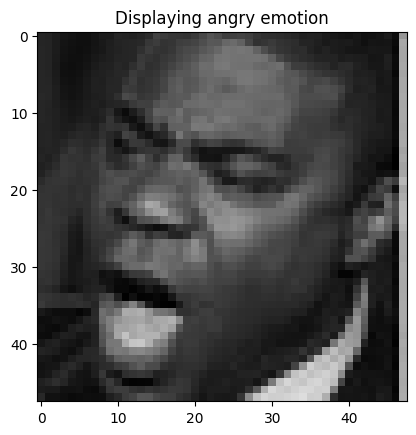

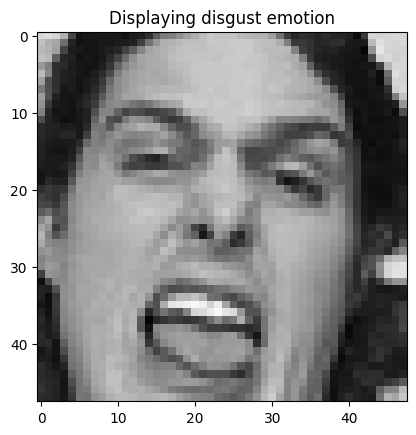

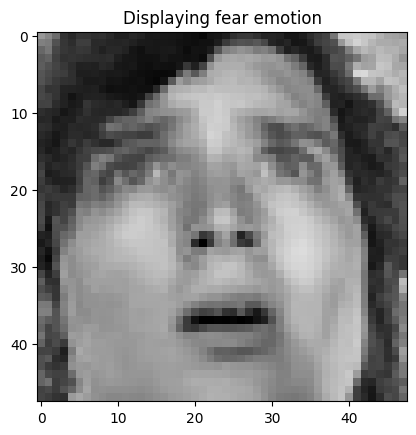

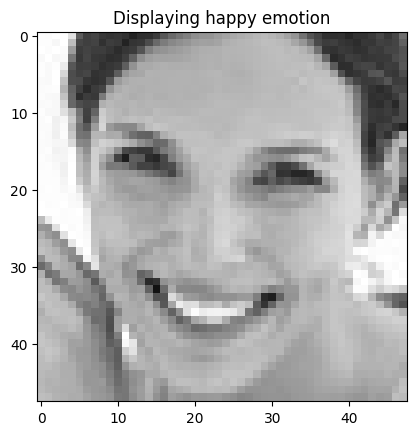

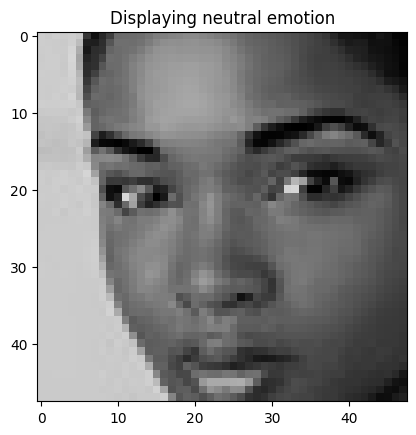

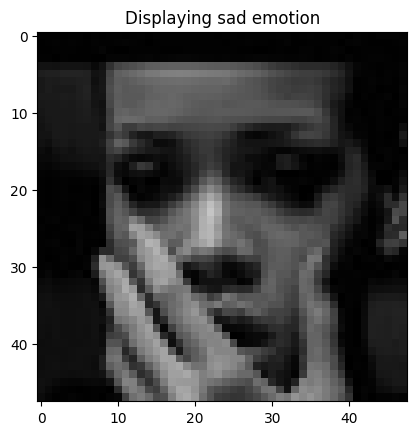

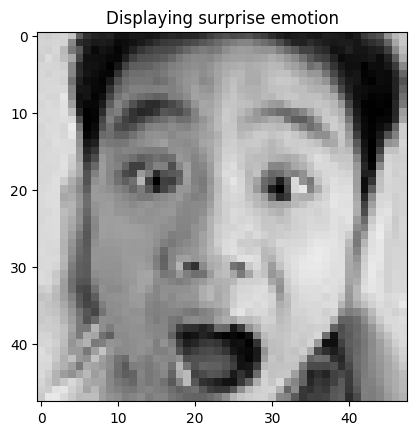

In [15]:
dataset_path = "/content/drive/MyDrive/0_MS_Projects/2.2 =  Deep Learning for Computer Vision = DeepFER: Facial Emotion Recognition Using Deep Learning/dataset/images/images"
emotions = []
for file_name in glob.glob(dataset_path+'/train/*/*'):
    emotion = file_name.split('/')[-2]
    if emotion not in emotions:
        img = cv2.imread(file_name)
        plt.imshow(img)
        plt.title("Displaying {} emotion".format(emotion))
        plt.show()
    emotions.append(emotion)

In [16]:
# dataset_path = "/kaggle/input/facial-emotion-recognition-model-dataset/images/images/"
# emotions = []
# for file_name in glob.glob(dataset_path+'/train/*/*'):
#     emotion = file_name.split('/')[-2]
#     if emotion not in emotions:
#         img = cv2.imread(file_name)
#         plt.imshow(img)
#         plt.title("Displaying {} emotion".format(emotion))
#         plt.show()
#     emotions.append(emotion)

## **Data Augmentation**

In [17]:
train_datagen = ImageDataGenerator(
    width_shift_range = 0.1,        # Randomly shift the width of images by up to 10%
    height_shift_range = 0.1,       # Randomly shift the height of images by up to 10%
    horizontal_flip = True,         # Flip images horizontally at random
    rescale = 1./255,               # Rescale pixel values to be between 0 and 1
    validation_split = 0.2          # Set aside 20% of the data for validation
)

validation_datagen = ImageDataGenerator(
    rescale = 1./255,               # Rescale pixel values to be between 0 and 1
    validation_split = 0.2          # Set aside 20% of the data for validation
)

In [18]:
train_generator = train_datagen.flow_from_directory(
    directory = train_dir,           # Directory containing the training data
    target_size = (48, 48),          # Resizes all images to 48x48 pixels
    batch_size = 64,                 # Number of images per batch
    color_mode = "grayscale",        # Converts the images to grayscale
    class_mode = "categorical",      # Classifies the images into 7 categories
    subset = "training"              # Uses the training subset of the data
)

validation_generator = validation_datagen.flow_from_directory(
    directory = test_dir,            # Directory containing the validation data
    target_size = (48, 48),          # Resizes all images to 48x48 pixels
    batch_size = 64,                 # Number of images per batch
    color_mode = "grayscale",        # Converts the images to grayscale
    class_mode = "categorical",      # Classifies the images into 7 categories
    subset = "validation"            # Uses the validation subset of the data
)

Found 23060 images belonging to 7 classes.
Found 1411 images belonging to 7 classes.


In [19]:
# Get the class indices (labels)
class_indices = train_generator.class_indices
print("Class Indices (Labels):", class_indices)

# Reverse the dictionary to get the class labels from indices
labels = {v: k for k, v in class_indices.items()}
print("Labels:", labels)

Class Indices (Labels): {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Labels: {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'}


In [20]:
img_shape=train_generator.image_shape
img_shape

(48, 48, 1)

## **CNN Model Custom Architecture**

To develop the CNN architecture, we will begin by defining the input layer and the number of filters in the first convolutional layer. Then, we will add additional convolutional layers with increasing numbers of filters, followed by max-pooling layers to reduce the spatial dimensions of the feature maps. After the convolutional layers, we will add fully connected layers with ReLU activation to classify the emotions.

We will experiment with different numbers of convolutional layers, filter sizes, and fully connected layers to optimize the model performance. Additionally, we will use techniques such as dropout and batch normalization to prevent overfitting and improve the generalization capability of the model.


In [21]:
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow as tf

# Define the input layer
inputs = Input(shape=(48, 48, 1), name='input_layer_2')

# Add a convolutional layer with 32 filters, 3x3 kernel size, and relu activation function
x = Conv2D(32, kernel_size=(3, 3), activation='relu')(inputs)
# Add a batch normalization layer
x = BatchNormalization()(x)

# Add a second convolutional layer with 64 filters, 3x3 kernel size, and relu activation function
x = Conv2D(64, kernel_size=(3, 3), activation='relu')(x)
# Add a second batch normalization layer
x = BatchNormalization()(x)
# Add a max pooling layer with 2x2 pool size
x = MaxPooling2D(pool_size=(2, 2))(x)
# Add a dropout layer with 0.25 dropout rate
x = Dropout(0.25)(x)

# Add a third convolutional layer with 128 filters, 3x3 kernel size, and relu activation function
x = Conv2D(128, kernel_size=(3, 3), activation='relu')(x)
# Add a third batch normalization layer
x = BatchNormalization()(x)

# Add a fourth convolutional layer with 128 filters, 3x3 kernel size, and relu activation function
x = Conv2D(128, kernel_size=(3, 3), activation='relu')(x)
# Add a fourth batch normalization layer
x = BatchNormalization()(x)
# Add a max pooling layer with 2x2 pool size
x = MaxPooling2D(pool_size=(2, 2))(x)
# Add a dropout layer with 0.25 dropout rate
x = Dropout(0.25)(x)

# Add a fifth convolutional layer with 256 filters, 3x3 kernel size, and relu activation function
x = Conv2D(256, kernel_size=(3, 3), activation='relu')(x)
# Add a fifth batch normalization layer
x = BatchNormalization()(x)

# Add a sixth convolutional layer with 256 filters, 3x3 kernel size, and relu activation function
x = Conv2D(256, kernel_size=(3, 3), activation='relu')(x)
# Add a sixth batch normalization layer
x = BatchNormalization()(x)
# Add a max pooling layer with 2x2 pool size
x = MaxPooling2D(pool_size=(2, 2))(x)
# Add a dropout layer with 0.25 dropout rate
x = Dropout(0.25)(x)

# Flatten the output of the convolutional layers
x = Flatten()(x)
# Add a dense layer with 256 neurons and relu activation function
x = Dense(256, activation='relu')(x)

# Add a seventh batch normalization layer
x = BatchNormalization()(x)
# Add a dropout layer with 0.5 dropout rate
x = Dropout(0.5)(x)
# Add a dense layer with 7 neurons (one for each class) and softmax activation function
outputs = Dense(7, activation='softmax')(x)

# Define the model
model = Model(inputs=inputs, outputs=outputs)

# Print the model summary
model.summary()




Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 44, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 44, 44, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 5, 5, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 5, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,02

 Total params: 1,394,183 (5.32 MB)

 Trainable params: 1,391,943 (5.31 MB)

 Non-trainable params: 2,240 (8.75 KB)

## **Compiling CNN Model**

In [22]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
  )

In [23]:
epochs = 42
batch_size = 64

## CNN Model Training

In [24]:
from tensorflow.keras.callbacks import ModelCheckpoint,ReduceLROnPlateau

# Lower the learning rate if accuracy stops improving.
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=8,
                                            verbose=1,
                                            factor=0.8,
                                            min_delta=1e-7,
                                            min_lr=1e-7)

# Define the filepath for saving the best model
model_checkpoint_path = 'best_model.h5'

# Define the callback
checkpoint_callback = ModelCheckpoint(
    model_checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks_list = [learning_rate_reduction, checkpoint_callback]



In [26]:
history = model.fit(x = train_generator,epochs = epochs,batch_size=batch_size,validation_data = validation_generator,callbacks=[callbacks_list])

Epoch 1/42
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - accuracy: 0.1707 - loss: 2.9037 
Epoch 1: val_accuracy improved from None to 0.26364, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 8779s 24s/step - accuracy: 0.1824 - loss: 2.7578 - val_accuracy: 0.2636 - val_loss: 1.9532 - learning_rate: 1.0000e-04
Epoch 2/42
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.2132 - loss: 2.4637
Epoch 2: val_accuracy improved from 0.26364 to 0.33735, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 56s 155ms/step - accuracy: 0.2252 - loss: 2.3954 - val_accuracy: 0.3373 - val_loss: 1.7351 - learning_rate: 1.0000e-04
Epoch 3/42
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.2423 - loss: 2.2645
Epoch 3: val_accuracy improved from 0.33735 to 0.35011, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 58s 160ms/step - accuracy: 0.2550 - loss: 2.2167 - val_accuracy: 0.3501 - val_loss: 1.6981 - learning_rate: 1.0000e-04
Epoch 4/42
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.2877 - loss: 2.0766
Epoch 4: val_accuracy improved from 0.35011 to 0.38979, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 56s 155ms/step - accuracy: 0.2902 - loss: 2.0695 - val_accuracy: 0.3898 - val_loss: 1.6245 - learning_rate: 1.0000e-04
Epoch 5/42
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.3107 - loss: 1.9751
Epoch 5: val_accuracy improved from 0.38979 to 0.39688, saving model to best_model.h5


...


Epoch 31: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 55s 152ms/step - accuracy: 0.5806 - loss: 1.1213 - val_accuracy: 0.5918 - val_loss: 1.0788 - learning_rate: 1.0000e-04
Epoch 32/42
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.5878 - loss: 1.0886
Epoch 32: val_accuracy did not improve from 0.59178
361/361 ━━━━━━━━━━━━━━━━━━━━ 54s 149ms/step - accuracy: 0.5840 - loss: 1.1030 - val_accuracy: 0.5797 - val_loss: 1.0851 - learning_rate: 1.0000e-04
Epoch 33/42
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.5820 - loss: 1.0984
Epoch 33: val_accuracy did not improve from 0.59178
361/361 ━━━━━━━━━━━━━━━━━━━━ 56s 156ms/step - accuracy: 0.5847 - loss: 1.0984 - val_accuracy: 0.5889 - val_loss: 1.0712 - learning_rate: 1.0000e-04
Epoch 34/42
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.5870 - loss: 1.0945
Epoch 34: val_accuracy did not improve from 0.59178
361/361 ━━━━━━━━━━━━━━━━━━━━ 59s 162ms/step - accuracy: 0.5893 - loss: 1.0864 - val


Epoch 36: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 59s 162ms/step - accuracy: 0.5995 - loss: 1.0701 - val_accuracy: 0.5946 - val_loss: 1.0436 - learning_rate: 1.0000e-04
Epoch 37/42
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.5974 - loss: 1.0642
Epoch 37: val_accuracy did not improve from 0.59461
361/361 ━━━━━━━━━━━━━━━━━━━━ 60s 165ms/step - accuracy: 0.6006 - loss: 1.0649 - val_accuracy: 0.5925 - val_loss: 1.0601 - learning_rate: 1.0000e-04
Epoch 38/42
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.6040 - loss: 1.0466
Epoch 38: val_accuracy improved from 0.59461 to 0.61162, saving model to best_model.h5



Epoch 38: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 58s 160ms/step - accuracy: 0.6036 - loss: 1.0530 - val_accuracy: 0.6116 - val_loss: 1.0220 - learning_rate: 1.0000e-04
Epoch 39/42
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.6153 - loss: 1.0398
Epoch 39: val_accuracy did not improve from 0.61162
361/361 ━━━━━━━━━━━━━━━━━━━━ 57s 157ms/step - accuracy: 0.6093 - loss: 1.0462 - val_accuracy: 0.5982 - val_loss: 1.0502 - learning_rate: 1.0000e-04
Epoch 40/42
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.6093 - loss: 1.0365
Epoch 40: val_accuracy did not improve from 0.61162
361/361 ━━━━━━━━━━━━━━━━━━━━ 56s 155ms/step - accuracy: 0.6050 - loss: 1.0445 - val_accuracy: 0.6088 - val_loss: 1.0597 - learning_rate: 1.0000e-04
Epoch 41/42
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.6049 - loss: 1.0395
Epoch 41: val_accuracy improved from 0.61162 to 0.61446, saving model to best_model.h5



Epoch 41: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 55s 152ms/step - accuracy: 0.6079 - loss: 1.0350 - val_accuracy: 0.6145 - val_loss: 1.0492 - learning_rate: 1.0000e-04
Epoch 42/42
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6148 - loss: 1.0174
Epoch 42: val_accuracy improved from 0.61446 to 0.61729, saving model to best_model.h5



Epoch 42: finished saving model to best_model.h5
361/361 ━━━━━━━━━━━━━━━━━━━━ 55s 151ms/step - accuracy: 0.6158 - loss: 1.0232 - val_accuracy: 0.6173 - val_loss: 1.0325 - learning_rate: 1.0000e-04


## CNN Model Evaluation

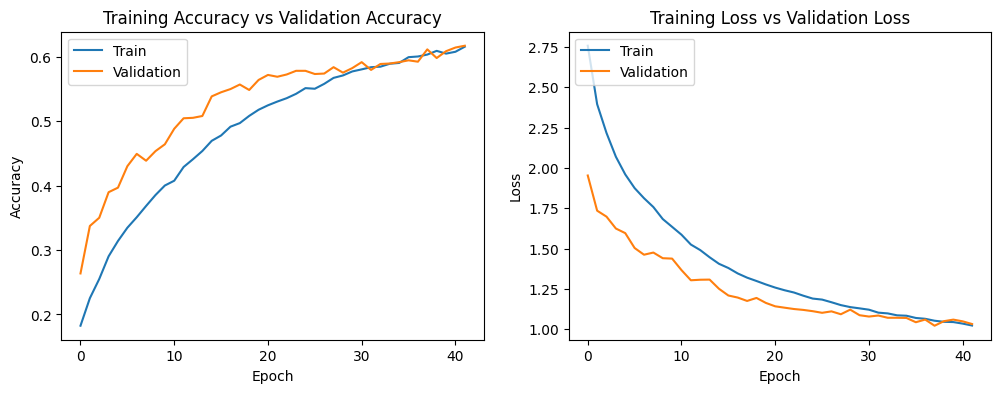

In [27]:
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
fig.set_size_inches(12,4)

# Plot the train and validation accuracy
ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Training Accuracy vs Validation Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train', 'Validation'], loc='upper left')

# Plot the train and validation Loss
ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Training Loss vs Validation Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train', 'Validation'], loc='upper left')

plt.show()

**Confusion Matrix**


23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step


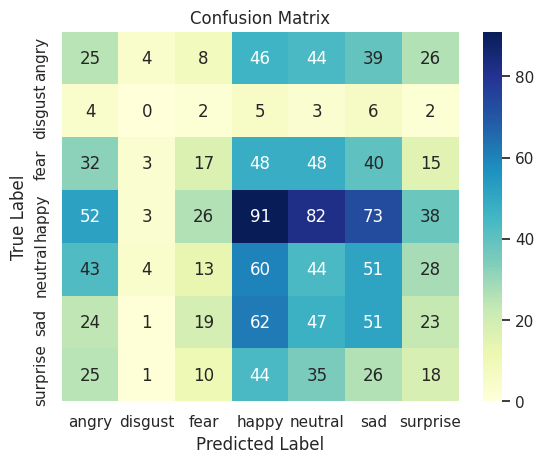

In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the true labels and predicted labels for the validation set
validation_labels = validation_generator.classes
validation_pred_probs = model.predict(validation_generator)
validation_pred_labels = np.argmax(validation_pred_probs, axis=1)

# Compute the confusion matrix
confusion_mtx = confusion_matrix(validation_labels, validation_pred_labels)
class_names = list(train_generator.class_indices.keys())
sns.set()
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [29]:
# Evaluate the model on training data
train_loss, train_accuracy = model.evaluate(train_generator, steps=len(train_generator))
print(f'Training Accuracy: {train_accuracy*100:.2f}%')

# Evaluate the model on validation data
val_loss, val_accuracy = model.evaluate(validation_generator, steps=len(validation_generator))
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

361/361 ━━━━━━━━━━━━━━━━━━━━ 53s 148ms/step - accuracy: 0.6558 - loss: 0.9172
Training Accuracy: 65.58%
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.6173 - loss: 1.0325
Validation Accuracy: 61.73%


## Testing Random Validation Data

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


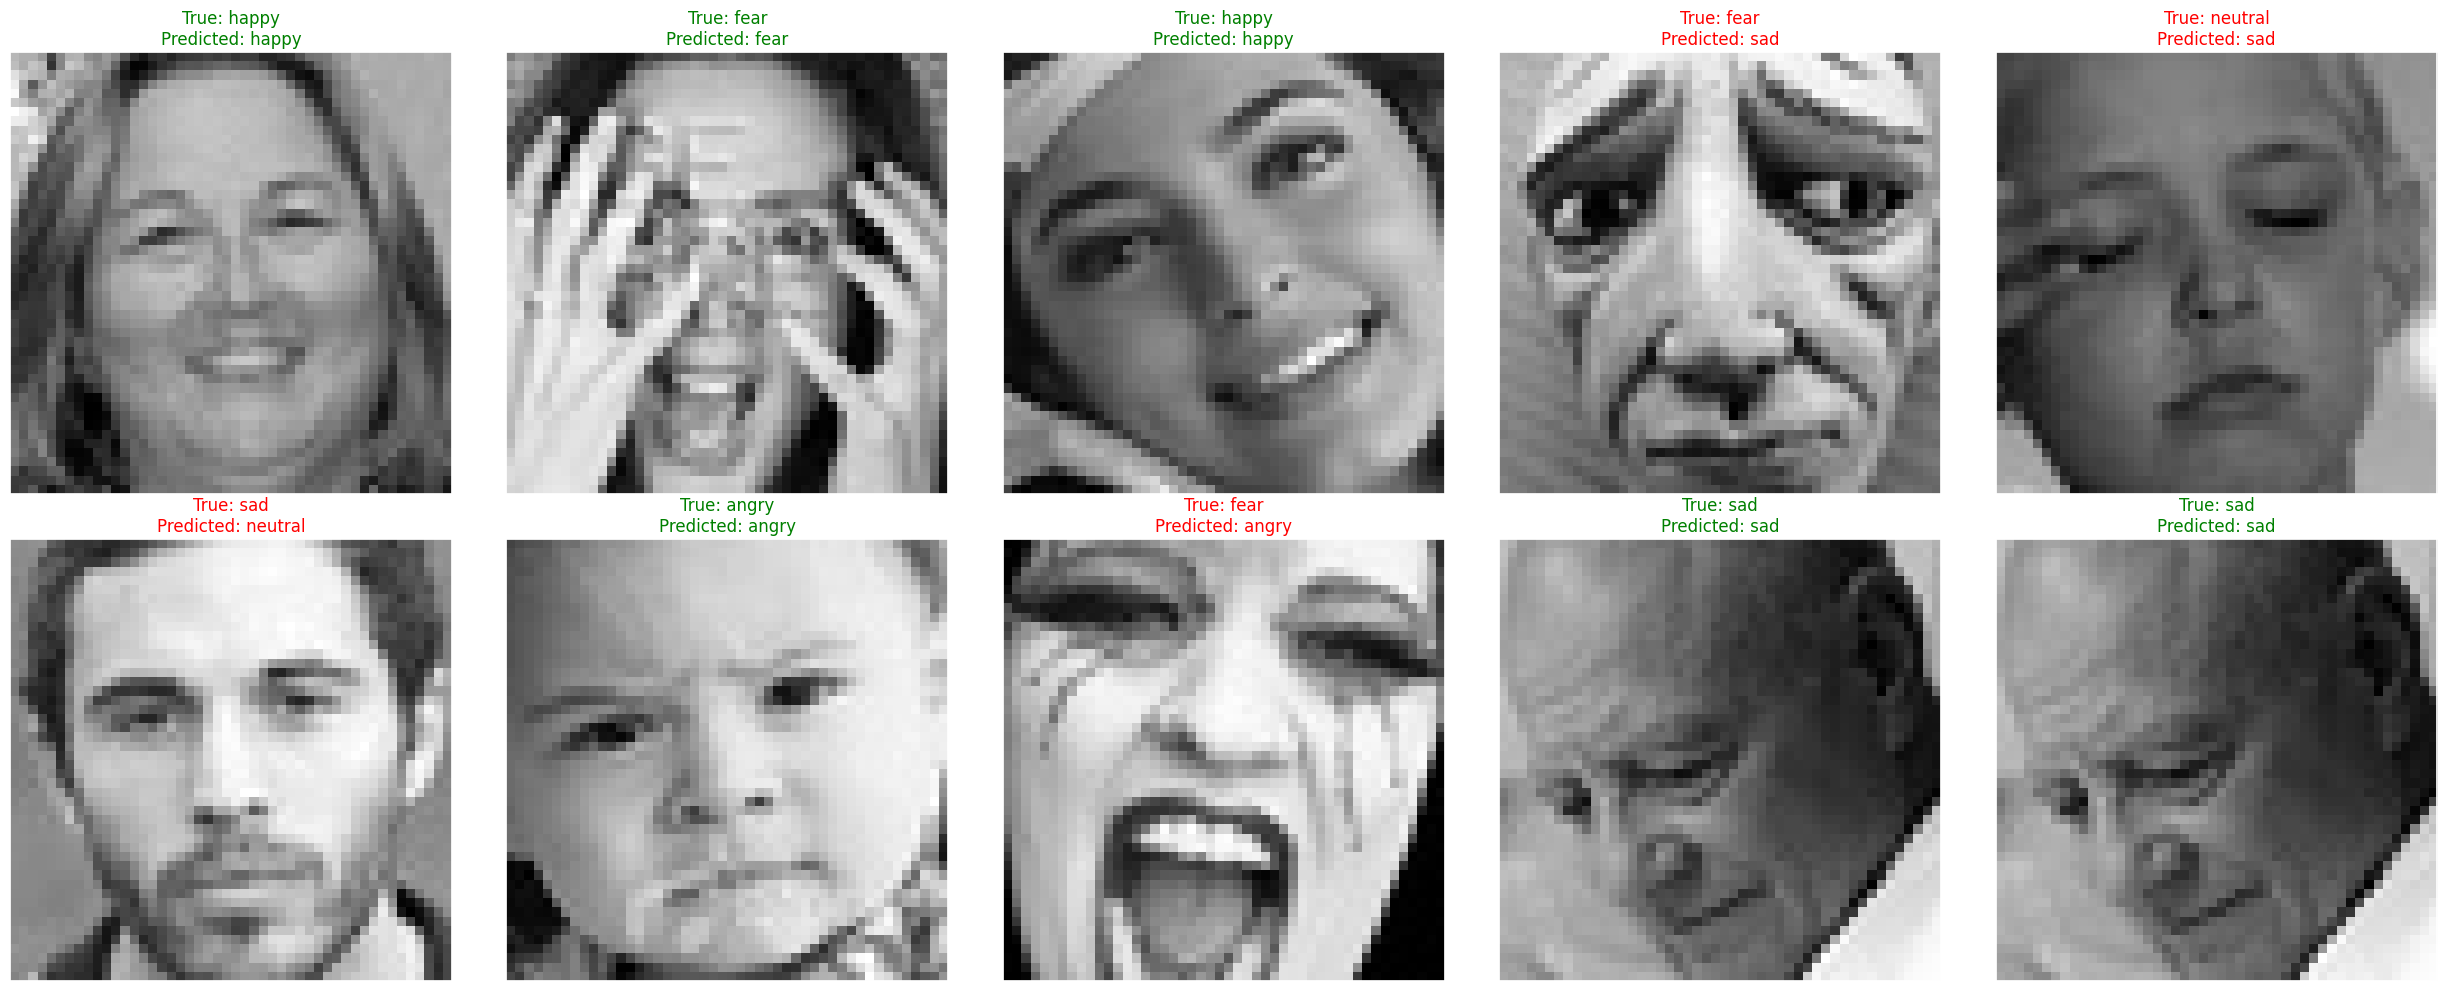

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Define the emotion labels
labels = {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'}



# Get the batch size from the validation generator
batch_size = validation_generator.batch_size

# Generate random batch and image indices
random_batch = np.random.randint(0, len(validation_generator) - 1)
random_img_indices = np.random.randint(0, batch_size, 10)

# Create a plot
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(25, 10), subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    # Get a random image and its true label from the validation data
    random_img = validation_generator[random_batch][0][random_img_indices[i]]
    random_img_label = np.argmax(validation_generator[random_batch][1][random_img_indices[i]])
    print(type(random_img))
    # Predict the label using the model
    model_prediction = np.argmax(model.predict(tf.expand_dims(random_img, axis=0), verbose=0))

    # Display the image
    ax.imshow(random_img.squeeze(), cmap='gray')

    # Determine the color of the title (green if correct, red if incorrect)
    if labels[random_img_label] == labels[model_prediction]:
        color = "green"
    else:
        color = "red"

    # Set the title of the subplot
    ax.set_title(f"True: {labels[random_img_label]}\nPredicted: {labels[model_prediction]}", color=color)

# Show the plot
plt.tight_layout()
plt.show()


## Saving the Model

In [31]:
# Save the entire model
model.save('cnn_model_new_.h5')

In [41]:
import cv2

# face_haar_cascade = cv2.CascadeClassifier('/content/drive/MyDrive/0_MS_Projects/2.2 =  Deep Learning for Computer Vision = DeepFER: Facial Emotion Recognition Using Deep Learning/Real Time Processing/haarcascade_frontalface_default.xml')

## **Transfer Learning Using ResNet50V2 Model**

In [44]:
# specifing new image shape for resnet
img_shape = 224
batch_size = 64

In [45]:
train_dir = "/content/drive/MyDrive/0_MS_Projects/2.2 =  Deep Learning for Computer Vision = DeepFER: Facial Emotion Recognition Using Deep Learning/dataset/images/images/train"
test_dir = "/content/drive/MyDrive/0_MS_Projects/2.2 =  Deep Learning for Computer Vision = DeepFER: Facial Emotion Recognition Using Deep Learning/dataset/images/images/validation"

## **Data Augmentation in ResNet50V2 Model**

In [47]:
train_preprocessor = ImageDataGenerator(
        rescale = 1 / 255.,
        rotation_range=10,
        zoom_range=0.2,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest',
    )


test_preprocessor = ImageDataGenerator(
    rescale = 1 / 255.,
)


In [48]:
train_data = train_preprocessor.flow_from_directory(
    train_dir,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size,
    subset='training',
)

test_data = test_preprocessor.flow_from_directory(
    test_dir,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode="rgb",
    shuffle=False,
    batch_size=batch_size,
)

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


## Fine-Tuning ResNet50V2

In [49]:
# 224,224,3
ResNet50V2 = tf.keras.applications.ResNet50V2(input_shape=(224, 224, 3),
                                               include_top= False,
                                               weights='imagenet'
                                               )

ResNet50V2.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 23,564,800 (89.89 MB)

 Trainable params: 23,519,360 (89.72 MB)

 Non-trainable params: 45,440 (177.50 KB)

In [50]:
# Freezing all layers except last 50

ResNet50V2.trainable = True

for layer in ResNet50V2.layers[:-50]:
    layer.trainable = False

## **Adding Custom Final Output Layers in ResNet50V2 Model**

In [51]:
def Create_ResNet50V2_Model():

    model = Sequential([
                      ResNet50V2,
                      Dropout(.25),
                      BatchNormalization(),
                      Flatten(),
                      Dense(64, activation='relu'),
                      BatchNormalization(),
                      Dropout(.5),
                      Dense(7,activation='softmax')
                    ])
    return model

In [52]:
ResNet50V2_Model = Create_ResNet50V2_Model()

ResNet50V2_Model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 7, 7, 2048)     │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,996,295 (114.43 MB)

 Trainable params: 22,779,527 (86.90 MB)

 Non-trainable params: 7,216,768 (27.53 MB)

In [53]:
ResNet50V2_Model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [54]:
from tensorflow.keras.callbacks import ModelCheckpoint,ReduceLROnPlateau,EarlyStopping

# Create Callback Checkpoint
checkpoint_path = "ResNet50V2_Best_Model.h5"

Checkpoint = ModelCheckpoint(checkpoint_path, monitor="val_accuracy", save_best_only=True,mode='max',verbose=1)

# Create Early Stopping Callback to monitor the accuracy
Early_Stopping = EarlyStopping(monitor = 'val_accuracy', patience = 7, restore_best_weights = True, verbose=1)

# Create ReduceLROnPlateau Callback to reduce overfitting by decreasing learning
Reducing_LR = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                  factor=0.2,
                                                  patience=2,
#                                                   min_lr=0.00005,
                                                  verbose=1)

callbacks = [Early_Stopping, Reducing_LR]

steps_per_epoch = train_data.n // train_data.batch_size
validation_steps = test_data.n // test_data.batch_size

## **Training the ResNet50V2 Model**

In [57]:
ResNet50V2_history = ResNet50V2_Model.fit(train_data ,validation_data = test_data , epochs=5, batch_size=batch_size,
                                         callbacks = callbacks, steps_per_epoch=steps_per_epoch, validation_steps=validation_steps)

Epoch 1/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 3996s 9s/step - accuracy: 0.5148 - loss: 1.3654 - val_accuracy: 0.5580 - val_loss: 1.2203 - learning_rate: 0.0010
Epoch 2/5
  1/450 ━━━━━━━━━━━━━━━━━━━━ 1:32 206ms/step - accuracy: 0.5938 - loss: 1.0742

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


450/450 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.5938 - loss: 1.0742 - val_accuracy: 0.5524 - val_loss: 1.2260 - learning_rate: 0.0010
Epoch 3/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 507s 1s/step - accuracy: 0.5744 - loss: 1.1720 - val_accuracy: 0.6109 - val_loss: 1.0759 - learning_rate: 0.0010
Epoch 4/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.6250 - loss: 1.1938 - val_accuracy: 0.6139 - val_loss: 1.0650 - learning_rate: 0.0010
Epoch 5/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 505s 1s/step - accuracy: 0.5964 - loss: 1.1147 - val_accuracy: 0.6021 - val_loss: 1.1545 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.


## ResNet50V2 Model Evaluation

In [58]:
ResNet50V2_Score = ResNet50V2_Model.evaluate(test_data)

print("    Test Loss: {:.5f}".format(ResNet50V2_Score[0]))
print("Test Accuracy: {:.2f}%".format(ResNet50V2_Score[1] * 100))

111/111 ━━━━━━━━━━━━━━━━━━━━ 29s 257ms/step - accuracy: 0.6144 - loss: 1.0635
    Test Loss: 1.06346
Test Accuracy: 61.44%


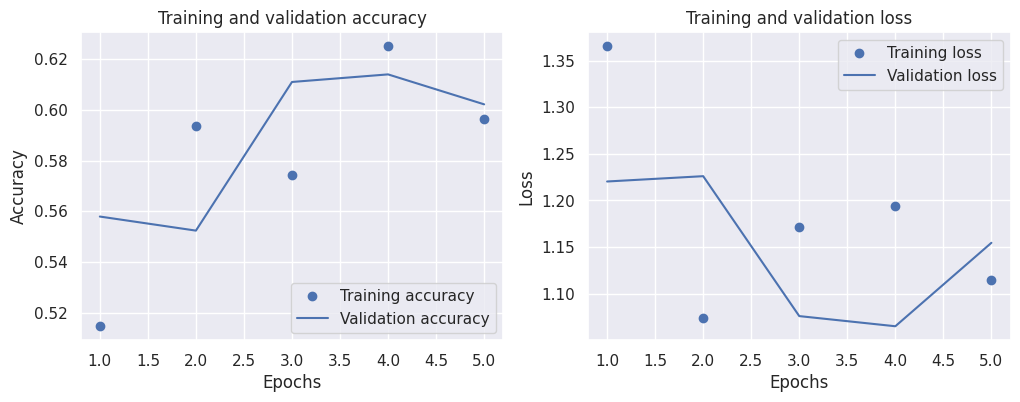

In [59]:
import matplotlib.pyplot as plt

def plot_curves(history):
    """
    Plot training & validation accuracy and loss curves.

    Parameters:
    history (History): The history object returned by the fit method of a Keras model.
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    # Plot training and validation accuracy
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo', label='Training accuracy')
    plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot training and validation loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Assuming ResNet50V2_history is the history object returned by the fit method of a Keras model
plot_curves(ResNet50V2_history)


In [60]:
ResNet50V2_Predictions = ResNet50V2_Model.predict(test_data)

# Choosing highest probalbilty class in every prediction
ResNet50V2_Predictions = np.argmax(ResNet50V2_Predictions, axis=1)

111/111 ━━━━━━━━━━━━━━━━━━━━ 31s 233ms/step


Text(0.5, 1.0, 'ResNet50V2 Confusion Matrix')

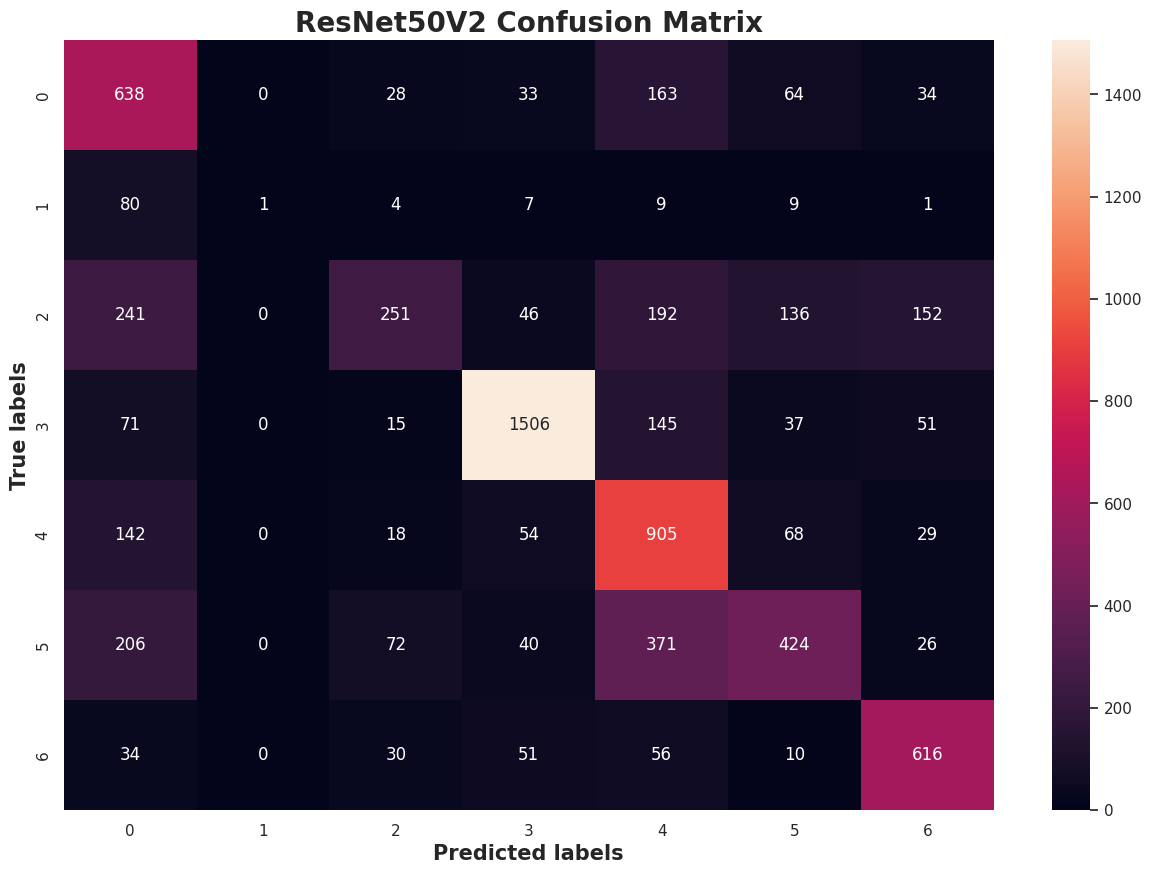

In [61]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
fig , ax= plt.subplots(figsize=(15,10))

cm=confusion_matrix(test_data.labels, ResNet50V2_Predictions)

sns.heatmap(cm, annot=True, fmt='g', ax=ax)

ax.set_xlabel('Predicted labels',fontsize=15, fontweight='bold')
ax.set_ylabel('True labels', fontsize=15, fontweight='bold')
ax.set_title('ResNet50V2 Confusion Matrix', fontsize=20, fontweight='bold')

## Testing Random Validation Data

In [62]:
Emotion_Classes = ['Angry',
                  'Disgust',
                  'Fear',
                  'Happy',
                  'Neutral',
                  'Sad',
                  'Surprise']

In [63]:
# Shuffling Test Data to show diffrent classes
test_preprocessor = ImageDataGenerator(
        rescale = 1 / 255.,
    )

test_generator = test_preprocessor.flow_from_directory(
    test_dir,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode="rgb",
    shuffle=True,
    batch_size=batch_size,
)

Found 7066 images belonging to 7 classes.


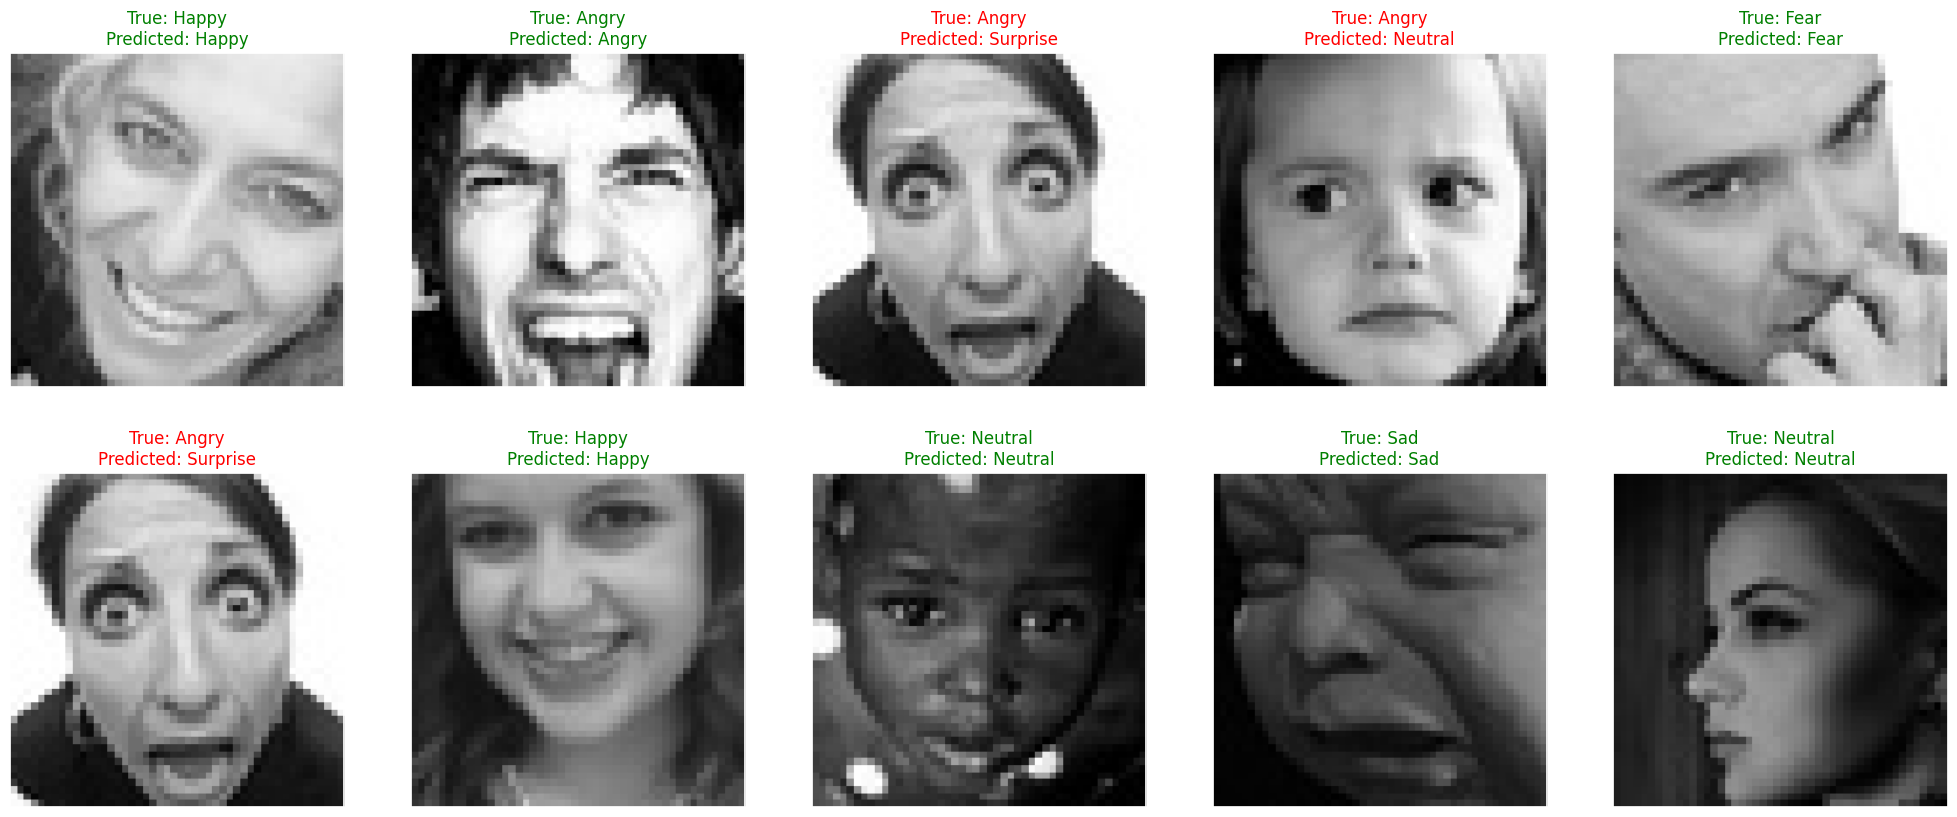

<Figure size 640x480 with 0 Axes>

In [64]:
# Display 10 random pictures from the dataset with their labels

Random_batch = np.random.randint(0, len(test_generator) - 1)

Random_Img_Index = np.random.randint(0, batch_size - 1 , 10)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(25, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):

    Random_Img = test_generator[Random_batch][0][Random_Img_Index[i]]

    Random_Img_Label = np.argmax(test_generator[Random_batch][1][Random_Img_Index[i]])

    Model_Prediction = np.argmax(ResNet50V2_Model.predict( tf.expand_dims(Random_Img, axis=0) , verbose=0))

    ax.imshow(Random_Img)

    if Emotion_Classes[Random_Img_Label] == Emotion_Classes[Model_Prediction]:
          color = "green"
    else:
          color = "red"
    ax.set_title(f"True: {Emotion_Classes[Random_Img_Label]}\nPredicted: {Emotion_Classes[Model_Prediction]}", color=color)
plt.show()
plt.tight_layout()


## Saving the ResNet50V2 Model

In [65]:
ResNet50V2_Model.save("ResNet50V2_Model.h5")